# Vision Transformer (ViT) Implementation

## Overview

This notebook implements a Vision Transformer from scratch using PyTorch.

ViT treats images as sequences of patches. It applies transformer architecture (originally designed for NLP) to computer vision tasks.

## Architecture Components

```mermaid
graph TD
    A[Input Image] --> B[Patch Embedding]
    B --> C[Add Position Embedding]
    C --> D[Add CLS Token]
    D --> E[Transformer Encoder Stack]
    E --> F[Layer Norm]
    F --> G[CLS Token]
    G --> H[Classification Head]
    H --> I[Output Classes]
```

## Data Flow

```mermaid
flowchart LR
    A["Image<br/>(32×32×3)"] --> B["Patches<br/>(64 patches)"]
    B --> C["Linear Projection<br/>(256-dim)"]
    C --> D["+ Position Embedding"]
    D --> E["Transformer Layers<br/>(6 layers)"]
    E --> F["CLS Token"]
    F --> G["MLP Head<br/>(10 classes)"]
```

## Key Ideas

**Patch Embedding**: Split image into fixed-size patches. Each patch becomes a token.

**Position Embedding**: Add learnable position info. Transformers have no built-in notion of order.

**CLS Token**: Special learnable token prepended to sequence. Used for classification.

**Multi-Head Attention**: Core mechanism. Allows model to focus on different parts of the image.

**MLP**: Feed-forward network applied after attention. Adds non-linearity and capacity.

# Setup

## Install Dependencies

Install PyTorch, torchvision, and matplotlib.

In [28]:
!pip install torch torchvision matplotlib

## Import Libraries

Core libraries:
- `torch`: Main PyTorch library
- `torch.nn`: Neural network modules
- `torchvision`: Vision datasets and transforms
- `matplotlib`: Plotting
- `typing`: Type hints for code clarity

In [29]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import numpy as np
import matplotlib.pyplot as plt
from torch import Tensor
from typing import Tuple, List
from matplotlib.axes import Axes
from matplotlib.figure import Figure

## Device Configuration

Check if GPU is available. Use GPU if present, otherwise CPU.

GPU training is much faster for neural networks.

In [30]:
# Set device
device: torch.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


## Hyperparameters

Key parameters that control model architecture and training:

**Training Parameters:**
- `BATCH_SIZE`: Number of images processed together (128)
- `EPOCHS`: Number of complete passes through dataset (5)
- `LEARNING_RATE`: Step size for optimizer (0.0003)

**Image Parameters:**
- `IMAGE_SIZE`: Input image dimensions (32×32 for CIFAR-10)
- `CHANNELS`: Color channels (3 for RGB)
- `PATCH_SIZE`: Size of each patch (4×4)

**Model Architecture:**
- `EMBED_DIM`: Dimension of embeddings (256)
- `NUM_HEADS`: Number of attention heads (8)
- `DEPTH`: Number of transformer layers (6)
- `MLP_DIM`: Hidden dimension in MLP (512)
- `DROP_RATE`: Dropout probability for regularization (0.1)
- `NUM_CLASSES`: Output classes (10 for CIFAR-10)

In [31]:
# Hyperparameters
BATCH_SIZE: int = 128
EPOCHS: int = 5
LEARNING_RATE: float = 3e-4
PATCH_SIZE: int = 4
NUM_CLASSES: int = 10
IMAGE_SIZE: int = 32
CHANNELS: int = 3
EMBED_DIM: int = 256
NUM_HEADS: int = 8
DEPTH: int = 6
MLP_DIM: int = 512
DROP_RATE: float = 0.1

# Preparing Dataset

## Data Preprocessing

Transform raw images to tensors and normalize.

**ToTensor**: Converts PIL Image or numpy array to tensor. Scales pixel values from [0, 255] to [0, 1].

**Normalize**: Shifts and scales values to [-1, 1] range. Helps with training stability.

## Splitting Dataset

## Load CIFAR-10 Dataset

CIFAR-10 contains 60,000 32×32 color images in 10 classes.

- Training set: 50,000 images
- Test set: 10,000 images

Classes: airplane, automobile, bird, cat, deer, dog, frog, horse, ship, truck

In [32]:
# Data preprocessing
transform: transforms.Compose = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

## Converting Dataset into Dataloaders
Currently, the dat is in the form of PyTorch Datasets.
Dataloader turns the data into batches (or mini-batches).
This has 2 benefits:
1. It is more computationally efficient as the GPU may not have enough memory to store the whole dataaset. Instead 128 images (batches) are processed at a time.
2. Using mini-batch gradient decient instead of batch-gradient descent meaning that updates are more frequent.

In [33]:
train_dataset: datasets.CIFAR10 = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
test_dataset: datasets.CIFAR10 = datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

## Create DataLoaders

DataLoader batches the data for efficient training.

**Benefits:**
1. **Memory Efficiency**: GPU can't hold entire dataset. Process in batches.
2. **Faster Convergence**: Mini-batch gradient descent updates weights more frequently.

`shuffle=True` for training randomizes order each epoch. Prevents overfitting to data order.

`shuffle=False` for testing keeps consistent evaluation.

In [34]:
train_loader: DataLoader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader: DataLoader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

### ViT components

# Vision Transformer Components

Now we implement the building blocks of ViT.

## 1. Patch Embedding

Converts image into sequence of patch embeddings.

**Process:**
1. Split image into patches using convolution
2. Flatten patches into vectors
3. Add special CLS token at start
4. Add position embeddings

```mermaid
graph LR
    A[Image] --> B[Conv2D<br/>Projection]
    B --> C[Flatten]
    C --> D[Add CLS Token]
    D --> E[Add Position]
    E --> F[Embedded Patches]
```

In [35]:
class PatchEmbedding(nn.Module):
    def __init__(self, img_size: int, patch_size: int, in_channels: int, embed_dim: int) -> None:
        super().__init__()
        self.patch_size: int = patch_size
        self.proj: nn.Conv2d = nn.Conv2d(in_channels, embed_dim, kernel_size=patch_size, stride=patch_size)
        num_patches: int = (img_size // patch_size) ** 2
        self.cls_token: nn.Parameter = nn.Parameter(torch.randn(1, 1, embed_dim))
        self.pos_embed: nn.Parameter = nn.Parameter(torch.randn(1, 1 + num_patches, embed_dim))

    def forward(self, x: Tensor) -> Tensor:
        B: int = x.size(0)
        x = self.proj(x)  # (B, E, H/P, W/P)
        x = x.flatten(2).transpose(1, 2)  # (B, N, E)
        cls_tokens: Tensor = self.cls_token.expand(B, -1, -1)
        x = torch.cat((cls_tokens, x), dim=1)
        x = x + self.pos_embed
        return x

## 2. Multi-Layer Perceptron (MLP)

Feed-forward network applied to each token independently.

**Architecture:**
- Linear layer: Expands dimension (256 → 512)
- GELU activation: Smooth non-linearity
- Dropout: Prevents overfitting
- Linear layer: Projects back (512 → 256)
- Dropout: More regularization

Used after attention in each transformer block.

In [36]:
class MLP(nn.Module):
    def __init__(self, in_features: int, hidden_features: int, drop_rate: float) -> None:
        super().__init__()
        self.fc1: nn.Linear = nn.Linear(in_features, hidden_features)
        self.fc2: nn.Linear = nn.Linear(hidden_features, in_features)
        self.dropout: nn.Dropout = nn.Dropout(drop_rate)

    def forward(self, x: Tensor) -> Tensor:
        x = self.dropout(F.gelu(self.fc1(x)))
        x = self.dropout(self.fc2(x))
        return x

## 3. Transformer Encoder Layer

Core building block. Combines attention and MLP with residual connections.

**Architecture:**
```
Input → LayerNorm → Multi-Head Attention → + (residual)
      ↓
      → LayerNorm → MLP → + (residual) → Output
```

**Key Features:**
- **LayerNorm**: Normalizes before attention and MLP
- **Multi-Head Attention**: Learns relationships between patches
- **Residual Connections**: Adds input to output (the `+`). Helps gradients flow.
- **MLP**: Adds capacity and non-linearity

In [37]:
class TransformerEncoderLayer(nn.Module):
    def __init__(self, embed_dim: int, num_heads: int, mlp_dim: int, drop_rate: float) -> None:
        super().__init__()
        self.norm1: nn.LayerNorm = nn.LayerNorm(embed_dim)
        self.attn: nn.MultiheadAttention = nn.MultiheadAttention(
            embed_dim, num_heads, dropout=drop_rate, batch_first=True
        )
        self.norm2: nn.LayerNorm = nn.LayerNorm(embed_dim)
        self.mlp: MLP = MLP(embed_dim, mlp_dim, drop_rate)

    def forward(self, x: Tensor) -> Tensor:
        x = x + self.attn(self.norm1(x), self.norm1(x), self.norm1(x))[0]
        x = x + self.mlp(self.norm2(x))
        return x

## 4. Complete Vision Transformer

Assembles all components into full model.

**Architecture Flow:**
1. **Patch Embedding**: Convert image to patch tokens
2. **Encoder Stack**: 6 transformer layers process patches
3. **Layer Norm**: Final normalization
4. **Classification Head**: Linear layer maps CLS token to classes

**Why CLS Token?**
The CLS token aggregates information from all patches through attention.
It's specifically designed for classification tasks.

In [38]:
class VisionTransformer(nn.Module):
    def __init__(
        self,
        img_size: int,
        patch_size: int,
        in_channels: int,
        num_classes: int,
        embed_dim: int,
        depth: int,
        num_heads: int,
        mlp_dim: int,
        drop_rate: float,
    ) -> None:
        super().__init__()
        self.patch_embed: PatchEmbedding = PatchEmbedding(img_size, patch_size, in_channels, embed_dim)
        self.encoder: nn.Sequential = nn.Sequential(
            *[TransformerEncoderLayer(embed_dim, num_heads, mlp_dim, drop_rate) for _ in range(depth)]
        )
        self.norm: nn.LayerNorm = nn.LayerNorm(embed_dim)
        self.head: nn.Linear = nn.Linear(embed_dim, num_classes)

    def forward(self, x: Tensor) -> Tensor:
        x = self.patch_embed(x)
        x = self.encoder(x)
        x = self.norm(x)
        cls_token = x[:, 0]
        return self.head(cls_token)

# Model Training

## Instantiate Model

Create VisionTransformer with our hyperparameters.

Move model to device (GPU/CPU) for training.

In [39]:
# Instantiate model
model: VisionTransformer = VisionTransformer(
    IMAGE_SIZE, PATCH_SIZE, CHANNELS, NUM_CLASSES,
    EMBED_DIM, DEPTH, NUM_HEADS, MLP_DIM, DROP_RATE
).to(device)

## Loss Function and Optimizer

**CrossEntropyLoss**: Standard loss for multi-class classification. Combines softmax and negative log-likelihood.

**Adam Optimizer**: Adaptive learning rate optimizer. Adjusts learning rate per parameter. Works well in practice.

In [40]:
# Loss and optimizer
criterion: nn.CrossEntropyLoss = nn.CrossEntropyLoss()
optimizer: optim.Adam = optim.Adam(model.parameters(), lr=LEARNING_RATE)

## Training Function

Trains model for one epoch.

**Steps per batch:**
1. Move data to device
2. Zero gradients from previous step
3. Forward pass: Compute predictions
4. Calculate loss
5. Backward pass: Compute gradients
6. Update weights

**Returns:** Average loss and accuracy for epoch

In [41]:
# Training loop
def train(model: nn.Module, loader: DataLoader, optimizer: optim.Optimizer, criterion: nn.Module) -> Tuple[float, float]:
    model.train()
    total_loss: float = 0.0
    correct: int = 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        out: Tensor = model(x)
        loss: Tensor = criterion(out, y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * x.size(0)
        correct += (out.argmax(1) == y).sum().item()
    return total_loss / len(loader.dataset), correct / len(loader.dataset)

## Evaluation Function

Tests model on validation/test set.

**Key Differences from Training:**
- `model.eval()`: Sets model to evaluation mode
- `torch.no_grad()`: Disables gradient calculation. Saves memory and computation.
- No weight updates

**Returns:** Accuracy on test set

In [42]:
# Evaluation loop
def evaluate(model: nn.Module, loader: DataLoader) -> float:
    model.eval()
    correct: int = 0
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            out: Tensor = model(x)
            correct += (out.argmax(1) == y).sum().item()
    return correct / len(loader.dataset)

## Run Training Loop

Train for specified number of epochs.

Each epoch:
1. Train on full training set
2. Evaluate on test set
3. Print and store metrics

Track accuracies for plotting later.

In [43]:
# Training
train_accuracies: List[float] = []
test_accuracies: List[float] = []
for epoch in range(EPOCHS):
    train_loss: float
    train_acc: float
    train_loss, train_acc = train(model, train_loader, optimizer, criterion)
    test_acc: float = evaluate(model, test_loader)
    train_accuracies.append(train_acc)
    test_accuracies.append(test_acc)
    print(f"Epoch {epoch+1}/{EPOCHS}, Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}, Test Acc: {test_acc:.4f}")

Epoch 1/5, Train Loss: 1.7208, Train Acc: 0.3771, Test Acc: 0.4735
Epoch 2/5, Train Loss: 1.3826, Train Acc: 0.5060, Test Acc: 0.5250
Epoch 3/5, Train Loss: 1.2467, Train Acc: 0.5540, Test Acc: 0.5704
Epoch 4/5, Train Loss: 1.1313, Train Acc: 0.5967, Test Acc: 0.5828
Epoch 5/5, Train Loss: 1.0409, Train Acc: 0.6287, Test Acc: 0.6032


# Results Visualization

## Plot Training Progress

Visualize how accuracy changes over epochs.

Compare train vs test accuracy to check for overfitting.

**Overfitting signs:** Large gap between train and test accuracy.

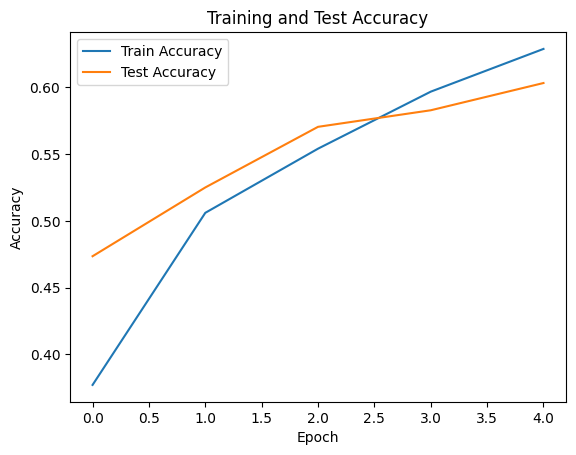

In [44]:
# Plot accuracy
plt.plot(train_accuracies, label='Train Accuracy')
plt.plot(test_accuracies, label='Test Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Training and Test Accuracy')
plt.show()

## Prediction Visualization Function

Creates grid of images with predictions.

**Process:**
1. Randomly sample images from dataset
2. Run model inference
3. Display image with true and predicted labels
4. Color code: Green (correct) or Red (incorrect)

**Inference Mode:** Disables gradient tracking for faster prediction.

In [45]:
import random

In [46]:
def predict_and_plot_grid(model: nn.Module, dataset: datasets.VisionDataset, classes: List[str], grid_size: int = 3) -> None:
	model.eval()
	fig: Figure
	axes: np.ndarray
	fig, axes = plt.subplots(grid_size, grid_size, figsize=(9, 9))
	for i in range(grid_size): # rows
		for j in range(grid_size): # columns
			idx: int = random.randint(0, len(dataset) - 1)
			img: Tensor
			true_label: int
			img, true_label = dataset[idx]
			input_tensor: Tensor = img.unsqueeze(dim=0).to(device)
			with torch.inference_mode():
				output: Tensor = model(input_tensor)
				predicted: Tensor
				_, predicted = torch.max(output.data, 1) 
			img_normalized: Tensor = img / 2 + 0.5 # unnormalise images as negative numbers are not supported
			np_img: np.ndarray = img_normalized.cpu().numpy()
			axes[i, j].imshow(np.transpose(np_img, (1,2,0))) # different order than PyTorch
			truth: bool = classes[true_label] == classes[predicted.item()]
			color: str
			if truth:
				color = "g"
			else:
				color = "r"
			axes[i, j].set_title(f"Truth: {classes[true_label]}\n, Predicted: {classes[predicted.item()]}", fontsize=10,color=color)
			axes[i, j].axis("off")
	plt.tight_layout()
	plt.show()

## Show Predictions

Display 3×3 grid of test images with predictions.

Visually assess model performance on individual samples.

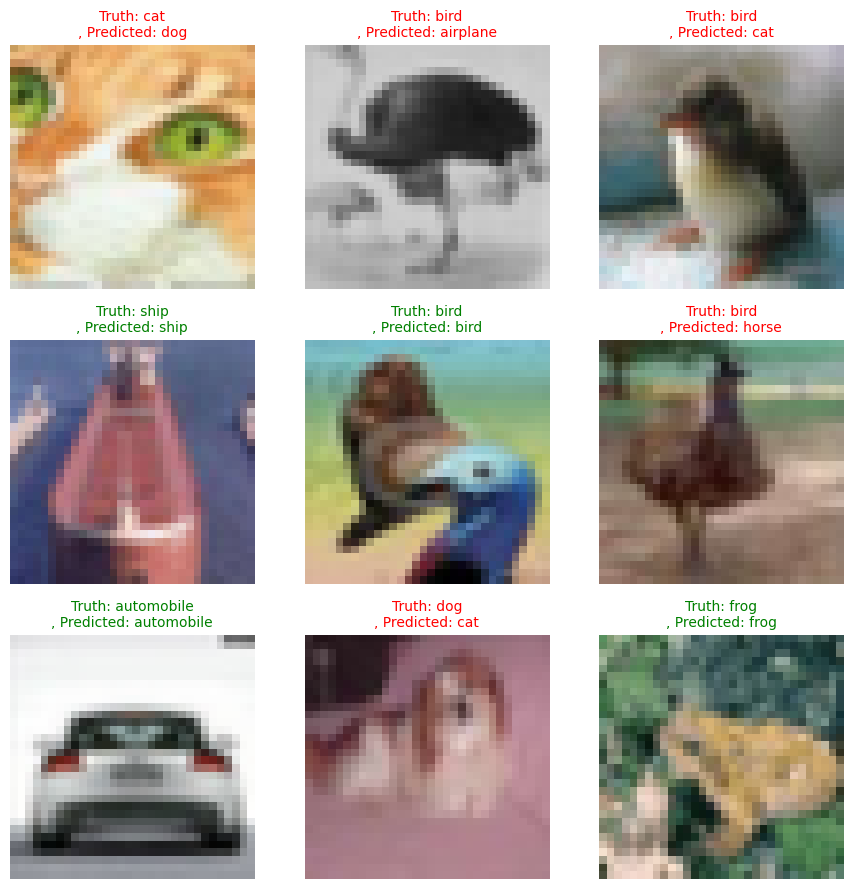

In [47]:
predict_and_plot_grid(model, test_dataset, classes=train_dataset.classes, grid_size=3)